<a href="https://colab.research.google.com/github/Dorcasi/hands-on-python-3084712/blob/main/Compiled_strains_Average_Permeability_Sample_D5H_xlsx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

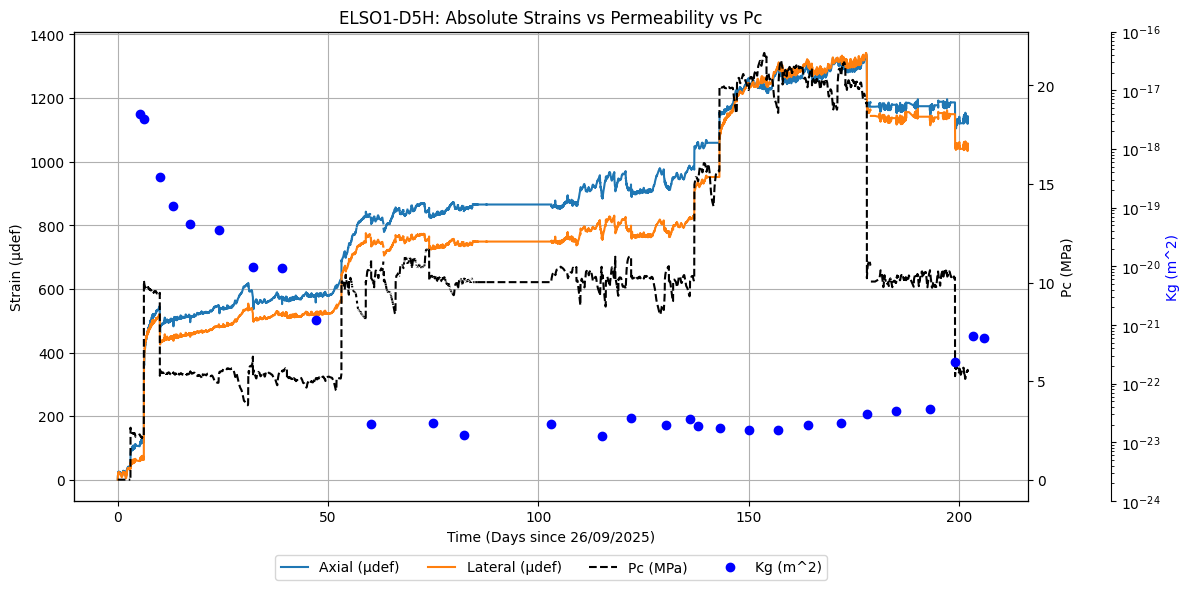

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H_copy.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

# --- Diagnostic: Print current columns to identify the mismatch ---
# print("Original columns of df1:", df1.columns.tolist())

# Select only the desired columns and rename them to remove extra spaces
df1 = df1[["Time (Date)", "Pc (MPa)", "Axial  (µdef)", "Lateral  (µdef)"]]
df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D5H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel(f"Time (Days since {start_date.strftime('%d/%m/%Y')})")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle="", label="Kg (m^2)")
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-24, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D5H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

# --- Diagnostic: Print current columns to identify the mismatch ---
print("Original columns of df1:", df1.columns.tolist())

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D5H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel(f"Time (Days since {start_date.strftime('%d/%m/%Y')})")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle="", label="Kg (m^2)")
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-24, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D5H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

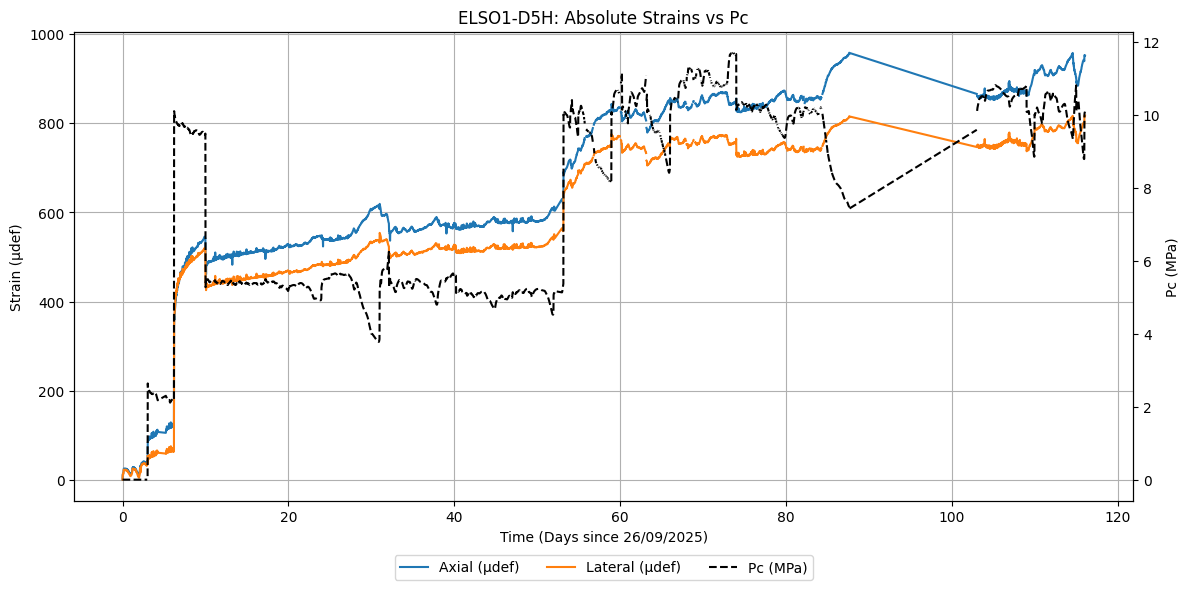

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D5H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel(f"Time (Days since {start_date.strftime('%d/%m/%Y')})")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis (Permeability) removed as per user request
# ax3 = ax1.twinx()
# ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
# ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
#          color="blue", marker="o", linestyle="-", label="Kg (m^2)")
# ax3.set_ylabel("Kg (m^2)", color="blue")
# ax3.set_yscale('log') # Set y-axis to logarithmic scale
# ax3.set_ylim(1e-24, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# lines3, labels3 = ax3.get_legend_handles_labels() # Removed permeability from legend
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D5H: Absolute Strains vs Pc") # Updated title
plt.tight_layout()
plt.show()

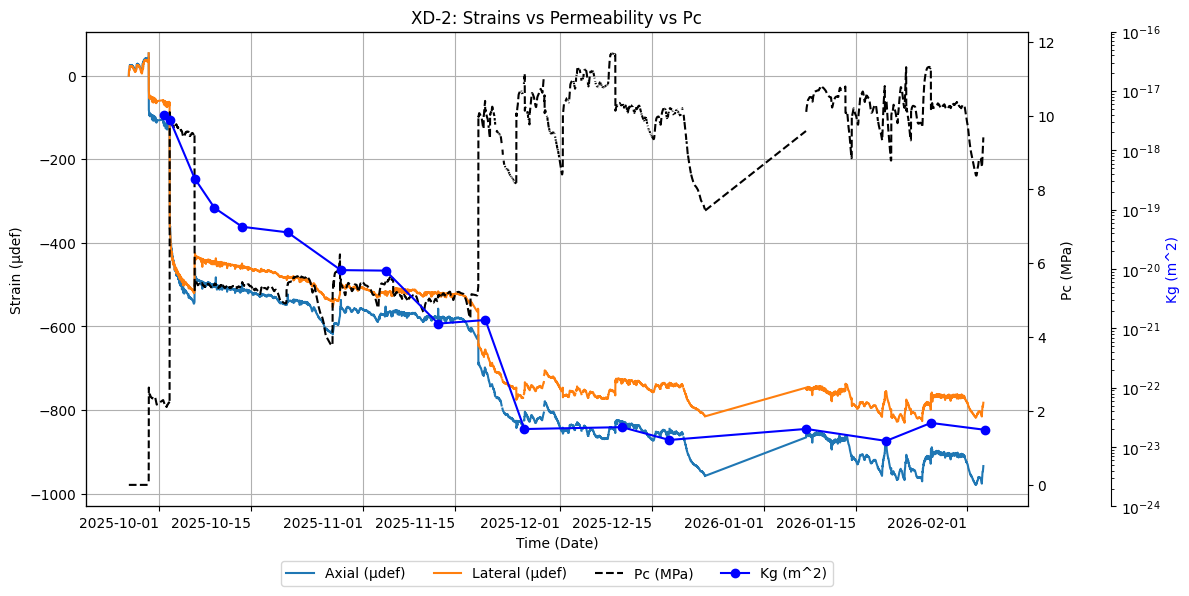

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D5H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled.index, df1_resampled[col], label=col)

ax1.set_xlabel("Time (Date)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled.index, df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2.index, df2["Kg (m^2)"],
         color="blue", marker="o", linestyle="-", label="Kg (m^2)")
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-24, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Format x-axis datetime labels
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate(rotation=0)

plt.title("XD-2: Strains vs Permeability vs Pc")
plt.tight_layout()
plt.show()

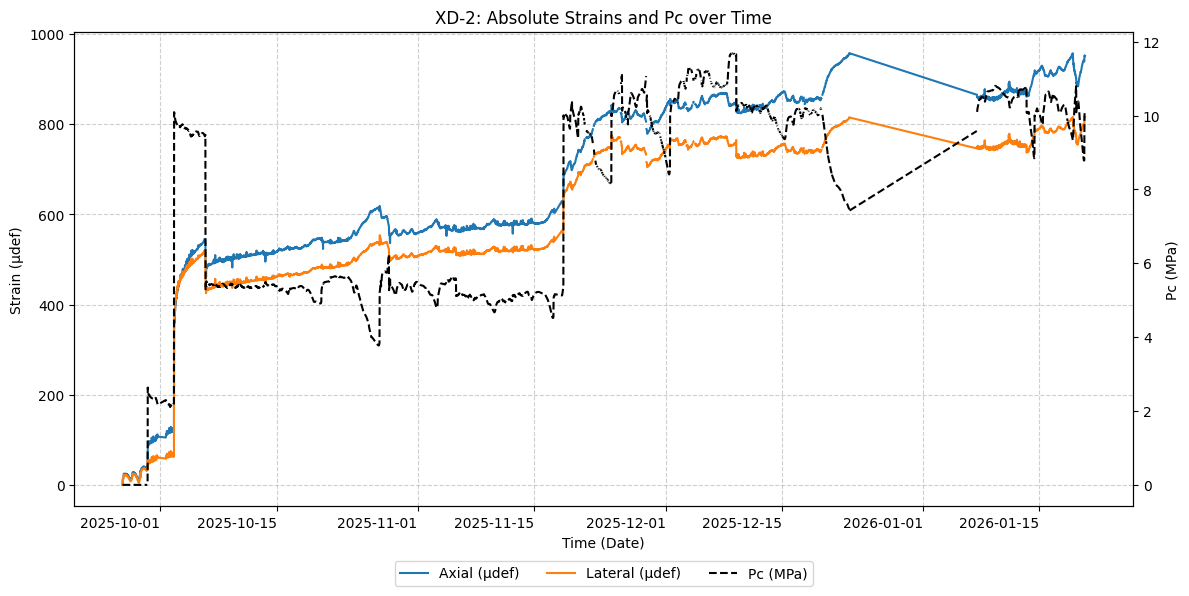

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
# Apply abs() to strain values
line_axial, = ax1.plot(df1_resampled.index, df1_resampled["Axial (µdef)"].abs(), label="Axial (µdef)")
line_lateral, = ax1.plot(df1_resampled.index, df1_resampled["Lateral (µdef)"].abs(), label="Lateral (µdef)")

ax1.set_xlabel("Time (Date)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True, linestyle = "--", alpha = 0.6)

# Secondary axis: Pc (MPa)
ax2 = ax1.twinx()
line_pc, = ax2.plot(df1_resampled.index, df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)") # Changed linestyle to ':' for dotted
ax2.set_ylabel("Pc (MPa)", color="black")
ax2.tick_params(axis='y', labelcolor="black")

# Combine legends
lines = [line_axial, line_lateral, line_pc]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=True)

# Format x-axis datetime labels
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate(rotation=0)

plt.title("XD-2: Absolute Strains and Pc over Time") # Updated title for clarity
plt.tight_layout()
plt.show()

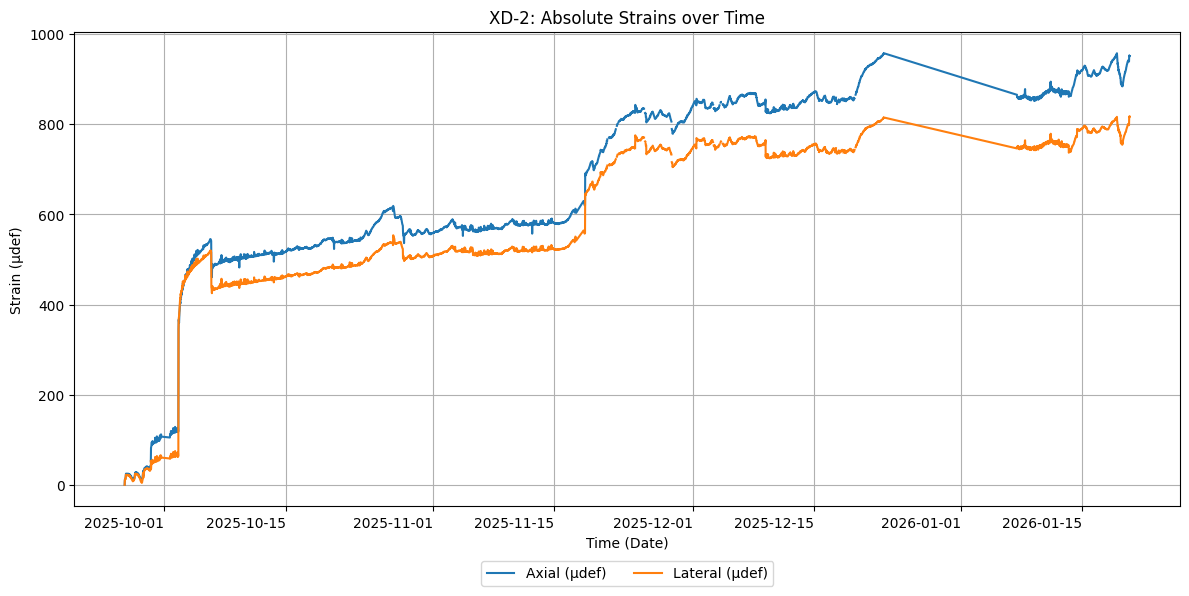

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
# Apply abs() to strain values
ax1.plot(df1_resampled.index, df1_resampled["Axial (µdef)"].abs(), label="Axial (µdef)")
ax1.plot(df1_resampled.index, df1_resampled["Lateral (µdef)"].abs(), label="Lateral (µdef)")

ax1.set_xlabel("Time (Date)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Only one legend for the strain data
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=True)

# Format x-axis datetime labels
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate(rotation=0)

plt.title("XD-2: Absolute Strains over Time")
plt.tight_layout()
plt.show()

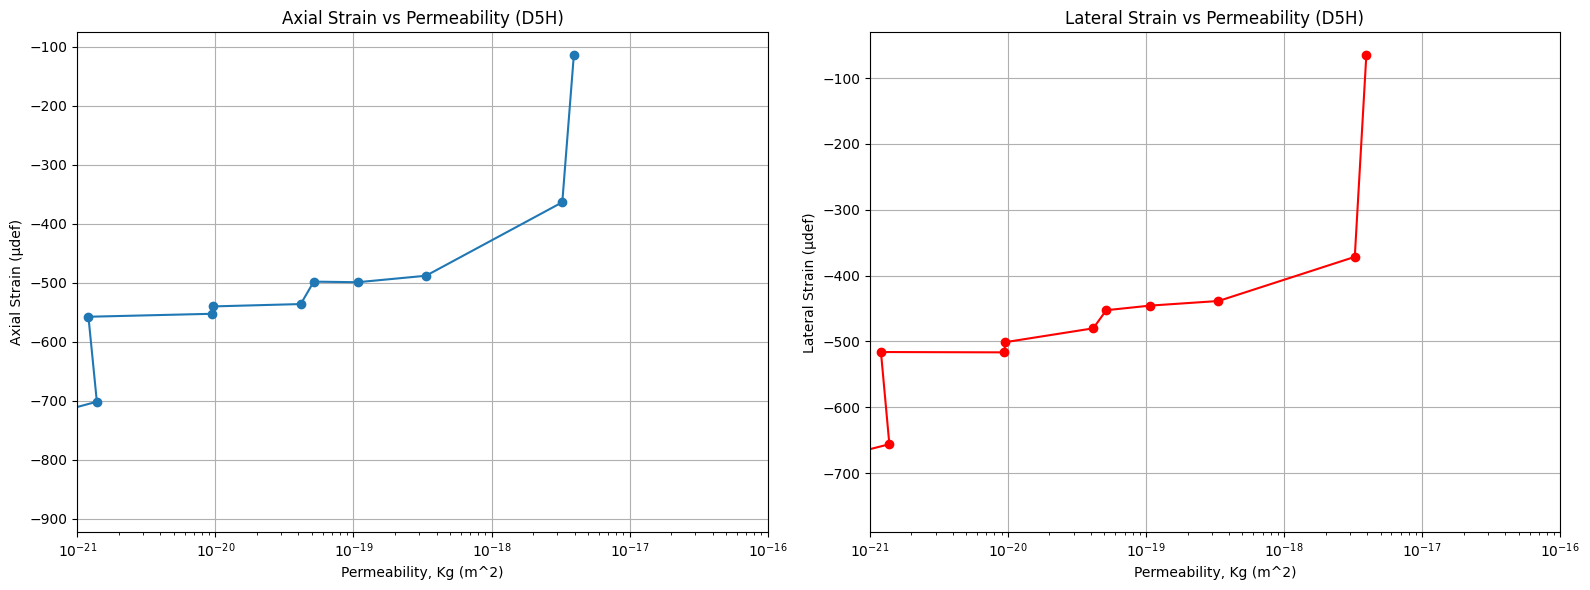

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# ---------- Graph of permeability versus strains alone (without time or Pc)

# ---------- Load first dataset (strains and P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx"
df1 = pd.read_excel(file1)
df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]
df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)
# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (permeability) ----------
file2 = "/content/Permeability_D5H.xlsx"
df2 = pd.read_excel(file2)
df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# Ensure both dataframes are sorted by their index (required for merge_asof)
df1_resampled = df1_resampled.sort_index()
df2 = df2.sort_index()

# ---------- Merge dataframes using merge_asof ----------
# This will find the nearest matching timestamp in df1_resampled for each timestamp in df2
# 'direction="nearest"' means it will look both backward and forward for the closest match
merged_df = pd.merge_asof(df2, df1_resampled, left_index=True, right_index=True, direction='nearest')

# ---------- Plotting ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # Two subplots side-by-side

# Plot Axial Strain vs Permeability
ax1.plot(merged_df["Kg (m^2)"], merged_df["Axial (µdef)"], 'o-', label="Axial (µdef)")
ax1.set_xlabel("Permeability, Kg (m^2)")
ax1.set_ylabel("Axial Strain (µdef)")
ax1.set_title("Axial Strain vs Permeability (D5H)")
ax1.grid(True)
ax1.set_xscale('log') # Permeability is often plotted on a log scale
ax1.set_xlim(1e-21, 1e-16) # Set the logarithmic x-axis limits

# Plot Lateral Strain vs Permeability
ax2.plot(merged_df["Kg (m^2)"], merged_df["Lateral (µdef)"], 'o-', color='red', label="Lateral (µdef)")
ax2.set_xlabel("Permeability, Kg (m^2)")
ax2.set_ylabel("Lateral Strain (µdef)")
ax2.set_title("Lateral Strain vs Permeability (D5H)")
ax2.grid(True)
ax2.set_xscale('log') # Permeability is often plotted on a log scale
ax2.set_xlim(1e-21, 1e-16) # Set the logarithmic x-axis limits

plt.tight_layout()
plt.show()

In [ ]:
print("df1_resampled date range:")
print(f"Start: {df1_resampled.index.min()}")
print(f"End: {df1_resampled.index.max()}\n")

print("df2 date range:")
print(f"Start: {df2.index.min()}")
print(f"End: {df2.index.max()}")

df1_resampled date range:
Start: 2025-09-26 10:13:55
End: 2025-11-20 16:18:28

df2 date range:
Start: 2025-10-01 16:53:20
End: 2025-11-19 15:23:58


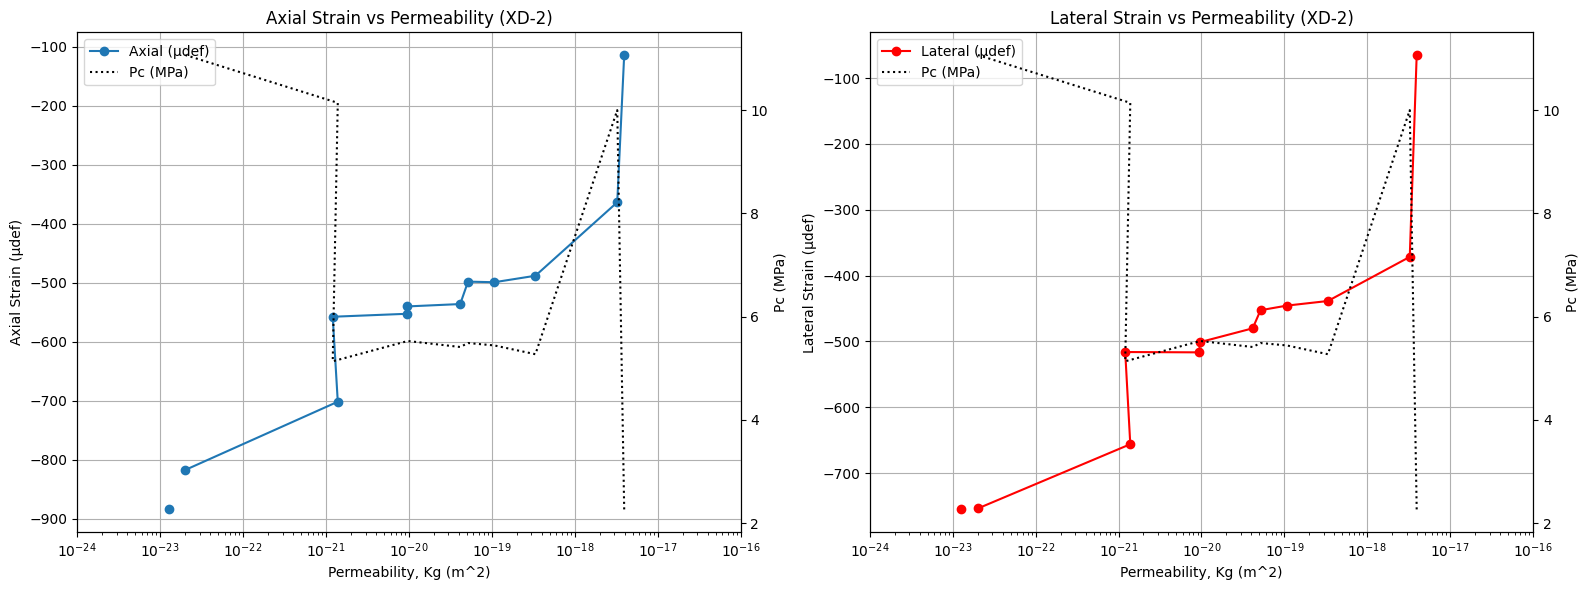

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load first dataset (strains and P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx"
df1 = pd.read_excel(file1)
df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]
df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)
# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (permeability) ----------
file2 = "/content/Permeability_D5H.xlsx"
df2 = pd.read_excel(file2)
df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# Ensure both dataframes are sorted by their index (required for merge_asof)
df1_resampled = df1_resampled.sort_index()
df2 = df2.sort_index()

# ---------- Merge dataframes using merge_asof ----------
# This will find the nearest matching timestamp in df1_resampled for each timestamp in df2
# 'direction="nearest"' means it will look both backward and forward for the closest match
merged_df = pd.merge_asof(df2, df1_resampled, left_index=True, right_index=True, direction='nearest')

# ---------- Plotting ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # Two subplots side-by-side

# --- Plot Axial Strain vs Permeability with Pc (MPa) ---
# Primary axis for Axial Strain
line1_ax1, = ax1.plot(merged_df["Kg (m^2)"], merged_df["Axial (µdef)"], 'o-', label="Axial (µdef)")
ax1.set_xlabel("Permeability, Kg (m^2)")
ax1.set_ylabel("Axial Strain (µdef)")
ax1.set_title("Axial Strain vs Permeability (XD-2)")
ax1.grid(True)
ax1.set_xscale('log') # Permeability is often plotted on a log scale
ax1.set_xlim(1e-24, 1e-16) # Set the logarithmic x-axis limits

# Secondary axis for Pc (MPa) on the first subplot
ax1_twin = ax1.twinx()
line2_ax1, = ax1_twin.plot(merged_df["Kg (m^2)"], merged_df["Pc (MPa)"],
                         color="black", linestyle=":", label="Pc (MPa)") # Dotted line
ax1_twin.set_ylabel("Pc (MPa)", color="black")
ax1_twin.tick_params(axis='y', labelcolor="black")

# Combine legends for the first subplot
lines_ax1 = [line1_ax1, line2_ax1]
labels_ax1 = [l.get_label() for l in lines_ax1]
ax1.legend(lines_ax1, labels_ax1, loc="upper left")


# --- Plot Lateral Strain vs Permeability with Pc (MPa) ---
# Primary axis for Lateral Strain
line1_ax2, = ax2.plot(merged_df["Kg (m^2)"], merged_df["Lateral (µdef)"], 'o-', color='red', label="Lateral (µdef)")
ax2.set_xlabel("Permeability, Kg (m^2)")
ax2.set_ylabel("Lateral Strain (µdef)")
ax2.set_title("Lateral Strain vs Permeability (XD-2)")
ax2.grid(True)
ax2.set_xscale('log') # Permeability is often plotted on a log scale
ax2.set_xlim(1e-24, 1e-16) # Set the logarithmic x-axis limits

# Secondary axis for Pc (MPa) on the second subplot
ax2_twin = ax2.twinx()
line2_ax2, = ax2_twin.plot(merged_df["Kg (m^2)"], merged_df["Pc (MPa)"],
                         color="black", linestyle=":", label="Pc (MPa)") # Dotted line
ax2_twin.set_ylabel("Pc (MPa)", color="black")
ax2_twin.tick_params(axis='y', labelcolor="black")

# Combine legends for the second subplot
lines_ax2 = [line1_ax2, line2_ax2]
labels_ax2 = [l.get_label() for l in lines_ax2]
ax2.legend(lines_ax2, labels_ax2, loc="upper left")


plt.tight_layout()
plt.show()

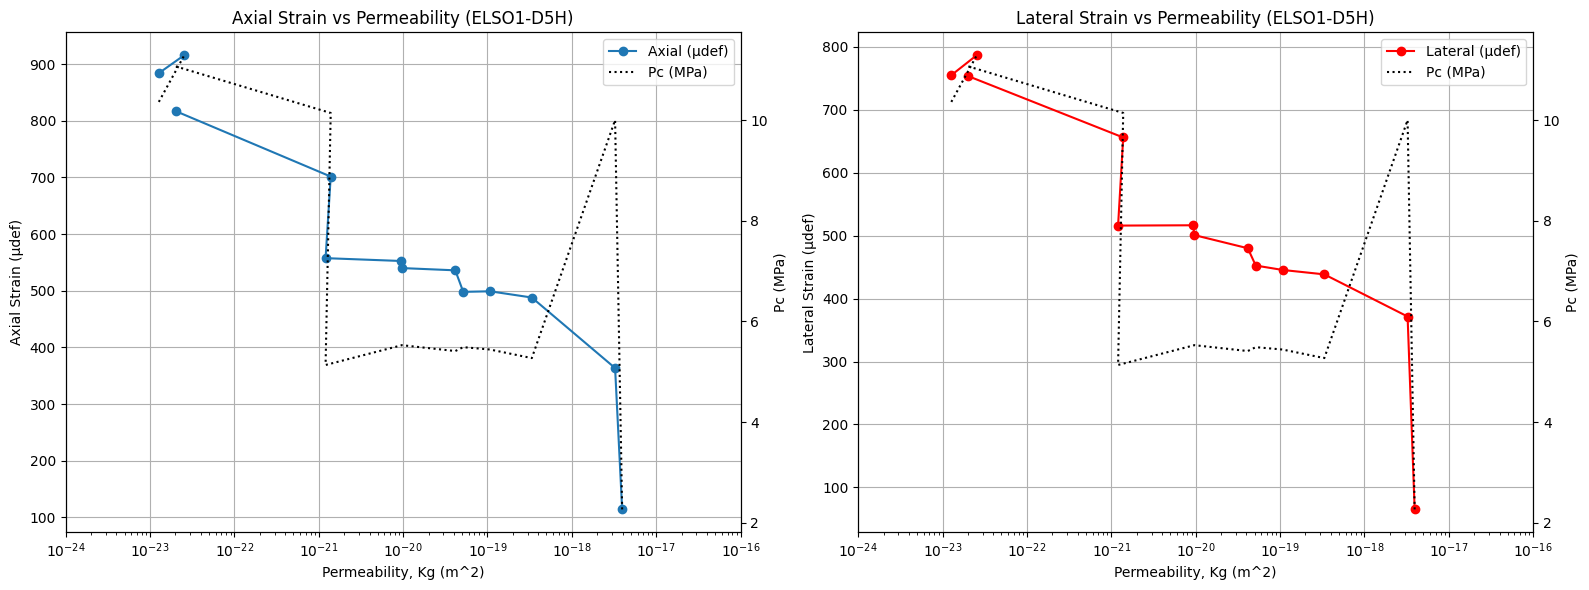

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load first dataset (strains and P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx"
df1 = pd.read_excel(file1)
df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]
df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)
# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (permeability) ----------
file2 = "/content/Permeability_D5H.xlsx"
df2 = pd.read_excel(file2)
df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# Ensure both dataframes are sorted by their index (required for merge_asof)
df1_resampled = df1_resampled.sort_index()
df2 = df2.sort_index()

# ---------- Merge dataframes using merge_asof ----------
# This will find the nearest matching timestamp in df1_resampled for each timestamp in df2
# 'direction="nearest"' means it will look both backward and forward for the closest match
merged_df = pd.merge_asof(df2, df1_resampled, left_index=True, right_index=True, direction='nearest')

# ---------- Plotting ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # Two subplots side-by-side

# --- Plot Axial Strain vs Permeability with Pc (MPa) ---
# Primary axis for Axial Strain
# Apply abs() to Axial (µdef)
line1_ax1, = ax1.plot(merged_df["Kg (m^2)"], merged_df["Axial (µdef)"].abs(), 'o-', label="Axial (µdef)")
ax1.set_xlabel("Permeability, Kg (m^2)")
ax1.set_ylabel("Axial Strain (µdef)")
ax1.set_title("Axial Strain vs Permeability (ELSO1-D5H)")
ax1.grid(True)
ax1.set_xscale('log') # Permeability is often plotted on a log scale
ax1.set_xlim(1e-24, 1e-16) # Set the logarithmic x-axis limits

# Secondary axis for Pc (MPa) on the first subplot
ax1_twin = ax1.twinx()
line2_ax1, = ax1_twin.plot(merged_df["Kg (m^2)"], merged_df["Pc (MPa)"],
                         color="black", linestyle=":", label="Pc (MPa)") # Dotted line
ax1_twin.set_ylabel("Pc (MPa)", color="black")
ax1_twin.tick_params(axis='y', labelcolor="black")

# Combine legends for the first subplot
lines_ax1 = [line1_ax1, line2_ax1]
labels_ax1 = [l.get_label() for l in lines_ax1]
ax1.legend(lines_ax1, labels_ax1, loc="upper right")


# --- Plot Lateral Strain vs Permeability with Pc (MPa) ---
# Primary axis for Lateral Strain
# Apply abs() to Lateral (µdef)
line1_ax2, = ax2.plot(merged_df["Kg (m^2)"], merged_df["Lateral (µdef)"].abs(), 'o-', color='red', label="Lateral (µdef)")
ax2.set_xlabel("Permeability, Kg (m^2)")
ax2.set_ylabel("Lateral Strain (µdef)")
ax2.set_title("Lateral Strain vs Permeability (ELSO1-D5H)")
ax2.grid(True)
ax2.set_xscale('log') # Permeability is often plotted on a log scale
ax2.set_xlim(1e-24, 1e-16) # Set the logarithmic x-axis limits

# Secondary axis for Pc (MPa) on the second subplot
ax2_twin = ax2.twinx()
line2_ax2, = ax2_twin.plot(merged_df["Kg (m^2)"], merged_df["Pc (MPa)"],
                         color="black", linestyle=":", label="Pc (MPa)") # Dotted line
ax2_twin.set_ylabel("Pc (MPa)", color="black")
ax2_twin.tick_params(axis='y', labelcolor="black")

# Combine legends for the second subplot
lines_ax2 = [line1_ax2, line2_ax2]
labels_ax2 = [l.get_label() for l in lines_ax2]
ax2.legend(lines_ax2, labels_ax2, loc="upper right")


plt.tight_layout()
plt.show()

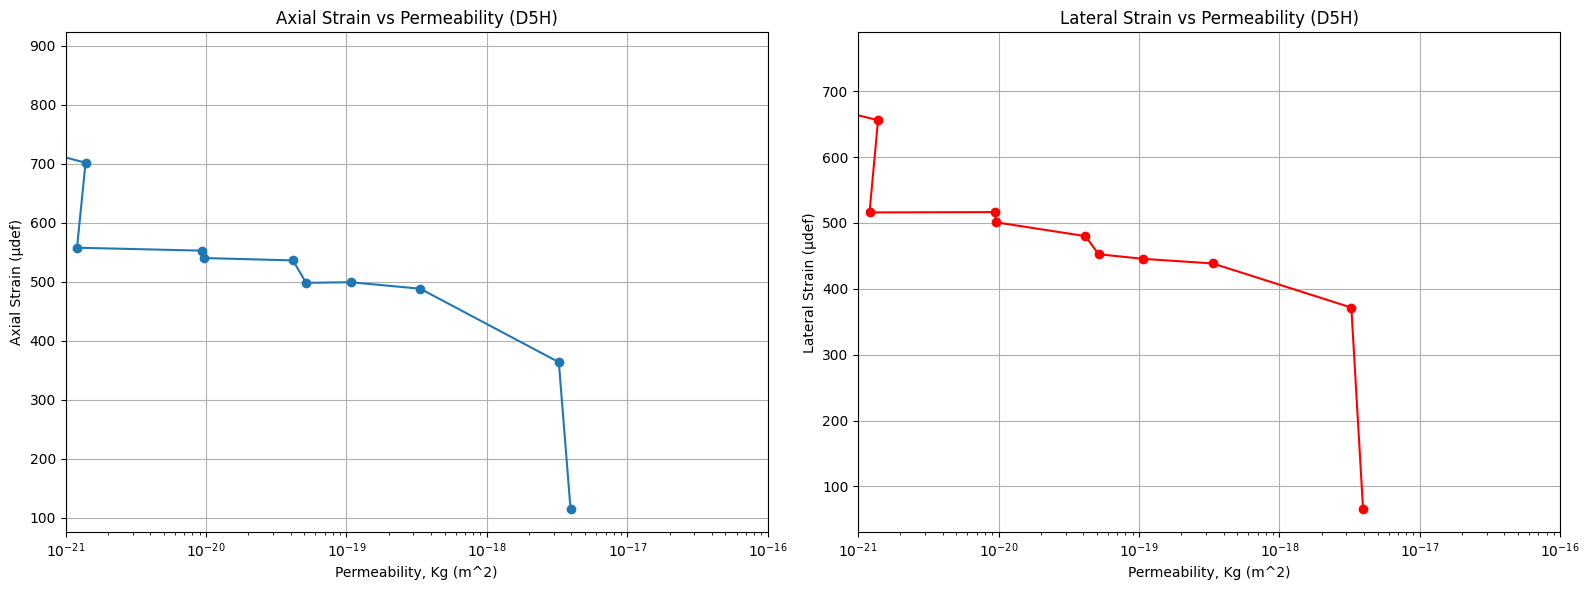

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load first dataset (strains and P_conf) ----------
file1 = "/content/Compiled_strains_Average_D5H.xlsx"
df1 = pd.read_excel(file1)
df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]
df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)
# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (permeability) ----------
file2 = "/content/Permeability_D5H.xlsx"
df2 = pd.read_excel(file2)
df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# Ensure both dataframes are sorted by their index (required for merge_asof)
df1_resampled = df1_resampled.sort_index()
df2 = df2.sort_index()

# ---------- Merge dataframes using merge_asof ----------
# This will find the nearest matching timestamp in df1_resampled for each timestamp in df2
# 'direction="nearest"' means it will look both backward and forward for the closest match
merged_df = pd.merge_asof(df2, df1_resampled, left_index=True, right_index=True, direction='nearest')

# ---------- Plotting ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) # Two subplots side-by-side

# --- Plot Axial Strain vs Permeability ---
# Primary axis for Axial Strain
# Apply abs() to Axial (µdef)
line1_ax1, = ax1.plot(merged_df["Kg (m^2)"], merged_df["Axial (µdef)"].abs(), 'o-', label="Axial (µdef)")
ax1.set_xlabel("Permeability, Kg (m^2)")
ax1.set_ylabel("Axial Strain (µdef)")
ax1.set_title("Axial Strain vs Permeability (D5H)")
ax1.grid(True)
ax1.set_xscale('log') # Permeability is often plotted on a log scale
ax1.set_xlim(1e-21, 1e-16) # Set the logarithmic x-axis limits

# Only one legend for the first subplot (Axial Strain)
#ax1.legend(loc="upper right")


# --- Plot Lateral Strain vs Permeability ---
# Primary axis for Lateral Strain
# Apply abs() to Lateral (µdef)
line1_ax2, = ax2.plot(merged_df["Kg (m^2)"], merged_df["Lateral (µdef)"].abs(), 'o-', color='red', label="Lateral (µdef)")
ax2.set_xlabel("Permeability, Kg (m^2)")
ax2.set_ylabel("Lateral Strain (µdef)")
ax2.set_title("Lateral Strain vs Permeability (D5H)")
ax2.grid(True)
ax2.set_xscale('log') # Permeability is often plotted on a log scale
ax2.set_xlim(1e-21, 1e-16) # Set the logarithmic x-axis limits

# Only one legend for the second subplot (Lateral Strain)
#ax2.legend(loc="upper right")


plt.tight_layout()
plt.show()